In [ ]:
import pandas as pd
import numpy as np
import joblib

try:
    from xgboost import XGBRegressor
    use_xgb = True
except:
    use_xgb = False

from google.colab import files
uploaded = files.upload()


Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume.csv


In [ ]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


# DATA CLEANING

In [ ]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [ ]:
df.isnull().sum()

,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [ ]:
df['holiday'].fillna('None', inplace=True)

/tmp/ipykernel_34882/1084375229.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['holiday'].fillna('None', inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(17)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


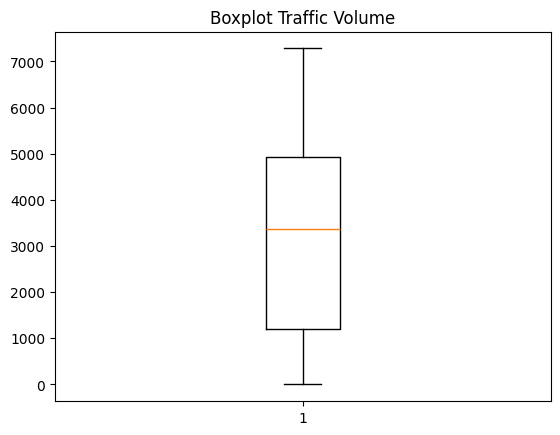

In [ ]:
# CEK OUTLIER
import matplotlib.pyplot as plt

plt.boxplot(df['traffic_volume'])
plt.title('Boxplot Traffic Volume')
plt.show()

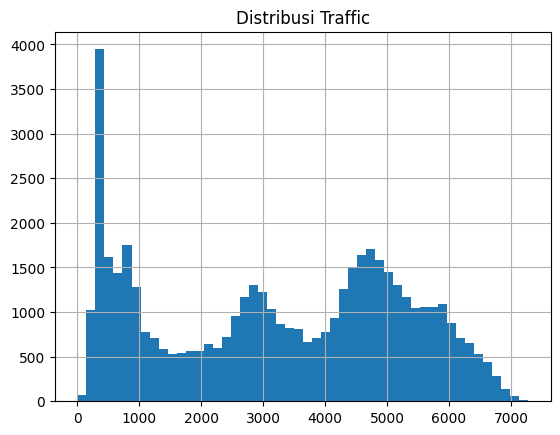

In [ ]:
df['traffic_volume'].hist(bins=50)
plt.title("Distribusi Traffic")
plt.show()

In [ ]:
low_traffic = df[
    (df['traffic_volume'] > 0) &
    (df['traffic_volume'] < 10)
]

print(len(low_traffic))
low_traffic

40


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
16849,None,295.27,0.00,0.0,1,Clear,sky is clear,2015-07-25 08:00:00,1
16850,None,295.82,0.00,0.0,1,Clear,sky is clear,2015-07-25 09:00:00,1
24821,None,294.63,0.00,0.0,40,Clouds,scattered clouds,2016-07-09 23:00:00,1
25157,None,295.85,0.00,0.0,1,Mist,mist,2016-07-23 00:00:00,6
25158,None,295.20,0.00,0.0,1,Clear,sky is clear,2016-07-23 01:00:00,8
25159,None,294.82,0.00,0.0,1,Mist,mist,2016-07-23 02:00:00,5
25160,None,294.42,0.00,0.0,1,Clear,sky is clear,2016-07-23 03:00:00,3
25161,None,294.19,0.00,0.0,1,Clear,sky is clear,2016-07-23 04:00:00,7
25167,None,299.12,0.00,0.0,75,Thunderstorm,proximity thunderstorm,2016-07-23 10:00:00,3
25171,None,295.30,9.42,0.0,90,Rain,heavy intensity rain,2016-07-23 12:00:00,2


In [ ]:
df['date_time'].describe()

,date_time
count,48187
unique,40575
top,2013-05-19 10:00:00
freq,6


In [ ]:
df['date_time'].value_counts().head(10)

,count
date_time,
2013-05-19 10:00:00,6
2013-04-18 22:00:00,6
2016-12-25 21:00:00,5
2012-12-16 19:00:00,5
2012-12-16 21:00:00,5
2013-12-16 10:00:00,5
2018-03-20 14:00:00,5
2012-11-11 04:00:00,5
2012-11-11 09:00:00,5


In [ ]:
df[df['date_time'] == '2013-05-19 10:00:00']

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
6162,None,287.15,0.0,0.0,90,Thunderstorm,thunderstorm with light rain,2013-05-19 10:00:00,3591
6163,None,287.15,0.0,0.0,90,Mist,mist,2013-05-19 10:00:00,3591
6164,None,287.15,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2013-05-19 10:00:00,3591
6165,None,287.15,0.0,0.0,90,Rain,moderate rain,2013-05-19 10:00:00,3591
6166,None,287.15,0.0,0.0,90,Rain,light rain,2013-05-19 10:00:00,3591
6167,None,287.15,0.0,0.0,90,Thunderstorm,thunderstorm with heavy rain,2013-05-19 10:00:00,3591


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    print(f"\n=== {col} ===")

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("Outliers:", len(outliers))


=== temp ===
Outliers: 10

=== rain_1h ===
Outliers: 3467

=== snow_1h ===
Outliers: 63

=== clouds_all ===
Outliers: 0

=== traffic_volume ===
Outliers: 0


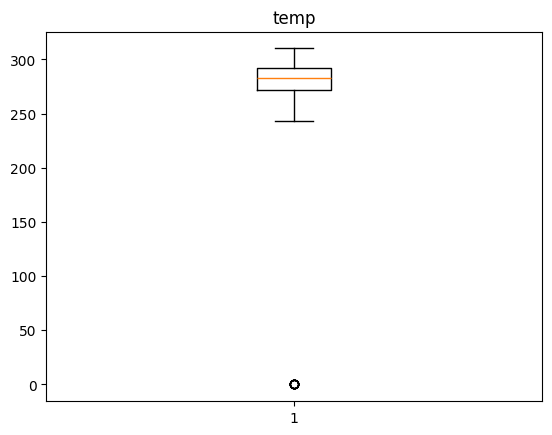

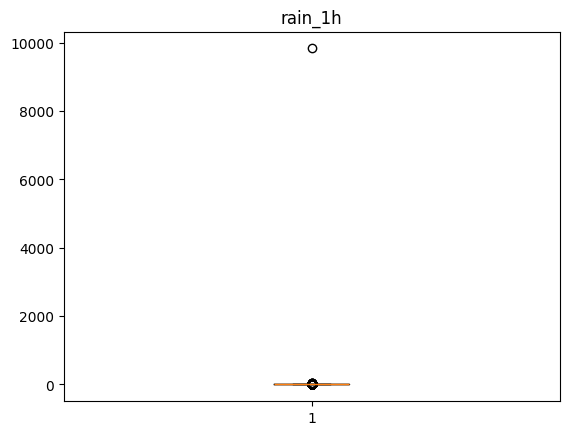

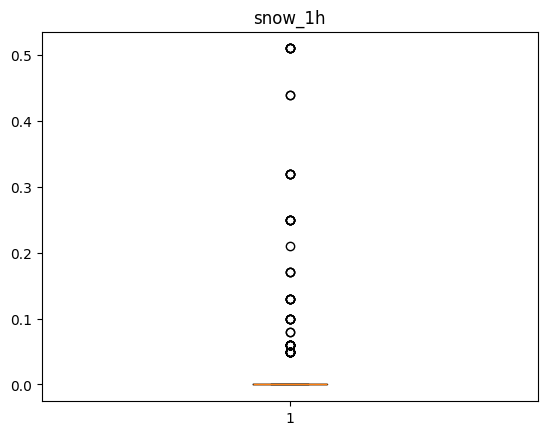

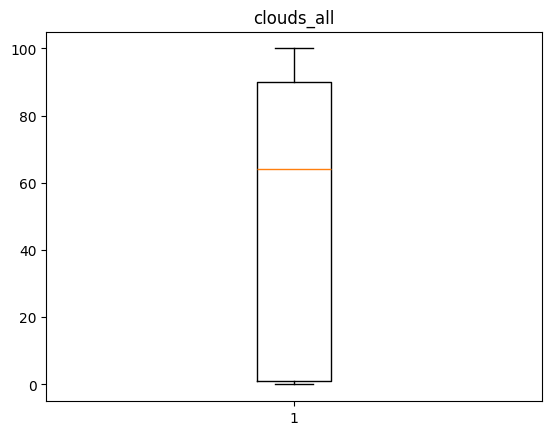

In [ ]:
feat_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']

for col in feat_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()
    print("\n")

In [ ]:
def show_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n=== {col} ===")
    print("Jumlah outlier:", len(outliers))
    return outliers

In [ ]:
cols = ['temp', 'rain_1h', 'snow_1h']

for col in cols:
    out = show_outliers(df, col)
    print(out.head())


=== temp ===
Jumlah outlier: 10
      holiday  temp  rain_1h  snow_1h  clouds_all weather_main  \
11898    None   0.0      0.0      0.0           0        Clear   
11899    None   0.0      0.0      0.0           0        Clear   
11900    None   0.0      0.0      0.0           0        Clear   
11901    None   0.0      0.0      0.0           0        Clear   
11946    None   0.0      0.0      0.0           0        Clear   

      weather_description            date_time  traffic_volume  
11898        sky is clear  2014-01-31 03:00:00             361  
11899        sky is clear  2014-01-31 04:00:00             734  
11900        sky is clear  2014-01-31 05:00:00            2557  
11901        sky is clear  2014-01-31 06:00:00            5150  
11946        sky is clear  2014-02-02 03:00:00             291  

=== rain_1h ===
Jumlah outlier: 3467
     holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
6688    None  288.86     0.25      0.0          92         Rain   
6689    

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean = df_clean[df_clean['temp'] > 200]
df_clean = df_clean[df_clean['rain_1h'] < 1000]

In [ ]:
# cek apakah masih ada temp aneh
print("Temp min:", df_clean['temp'].min())

# cek apakah masih ada rain ekstrem
print("Rain max:", df_clean['rain_1h'].max())

Temp min: 243.39
Rain max: 55.63


In [ ]:
df_clean.to_csv('traffic_clean.csv', index=False)

# EDA

In [ ]:
df_clean['date_time'] = pd.to_datetime(df_clean['date_time'])

df_clean['hour'] = df_clean['date_time'].dt.hour
df_clean['dayofweek'] = df_clean['date_time'].dt.dayofweek
df_clean['month'] = df_clean['date_time'].dt.month

df_clean['is_weekend'] = df_clean['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

df_clean['is_rush_hour'] = df_clean['hour'].apply(
    lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 18) else 0
)

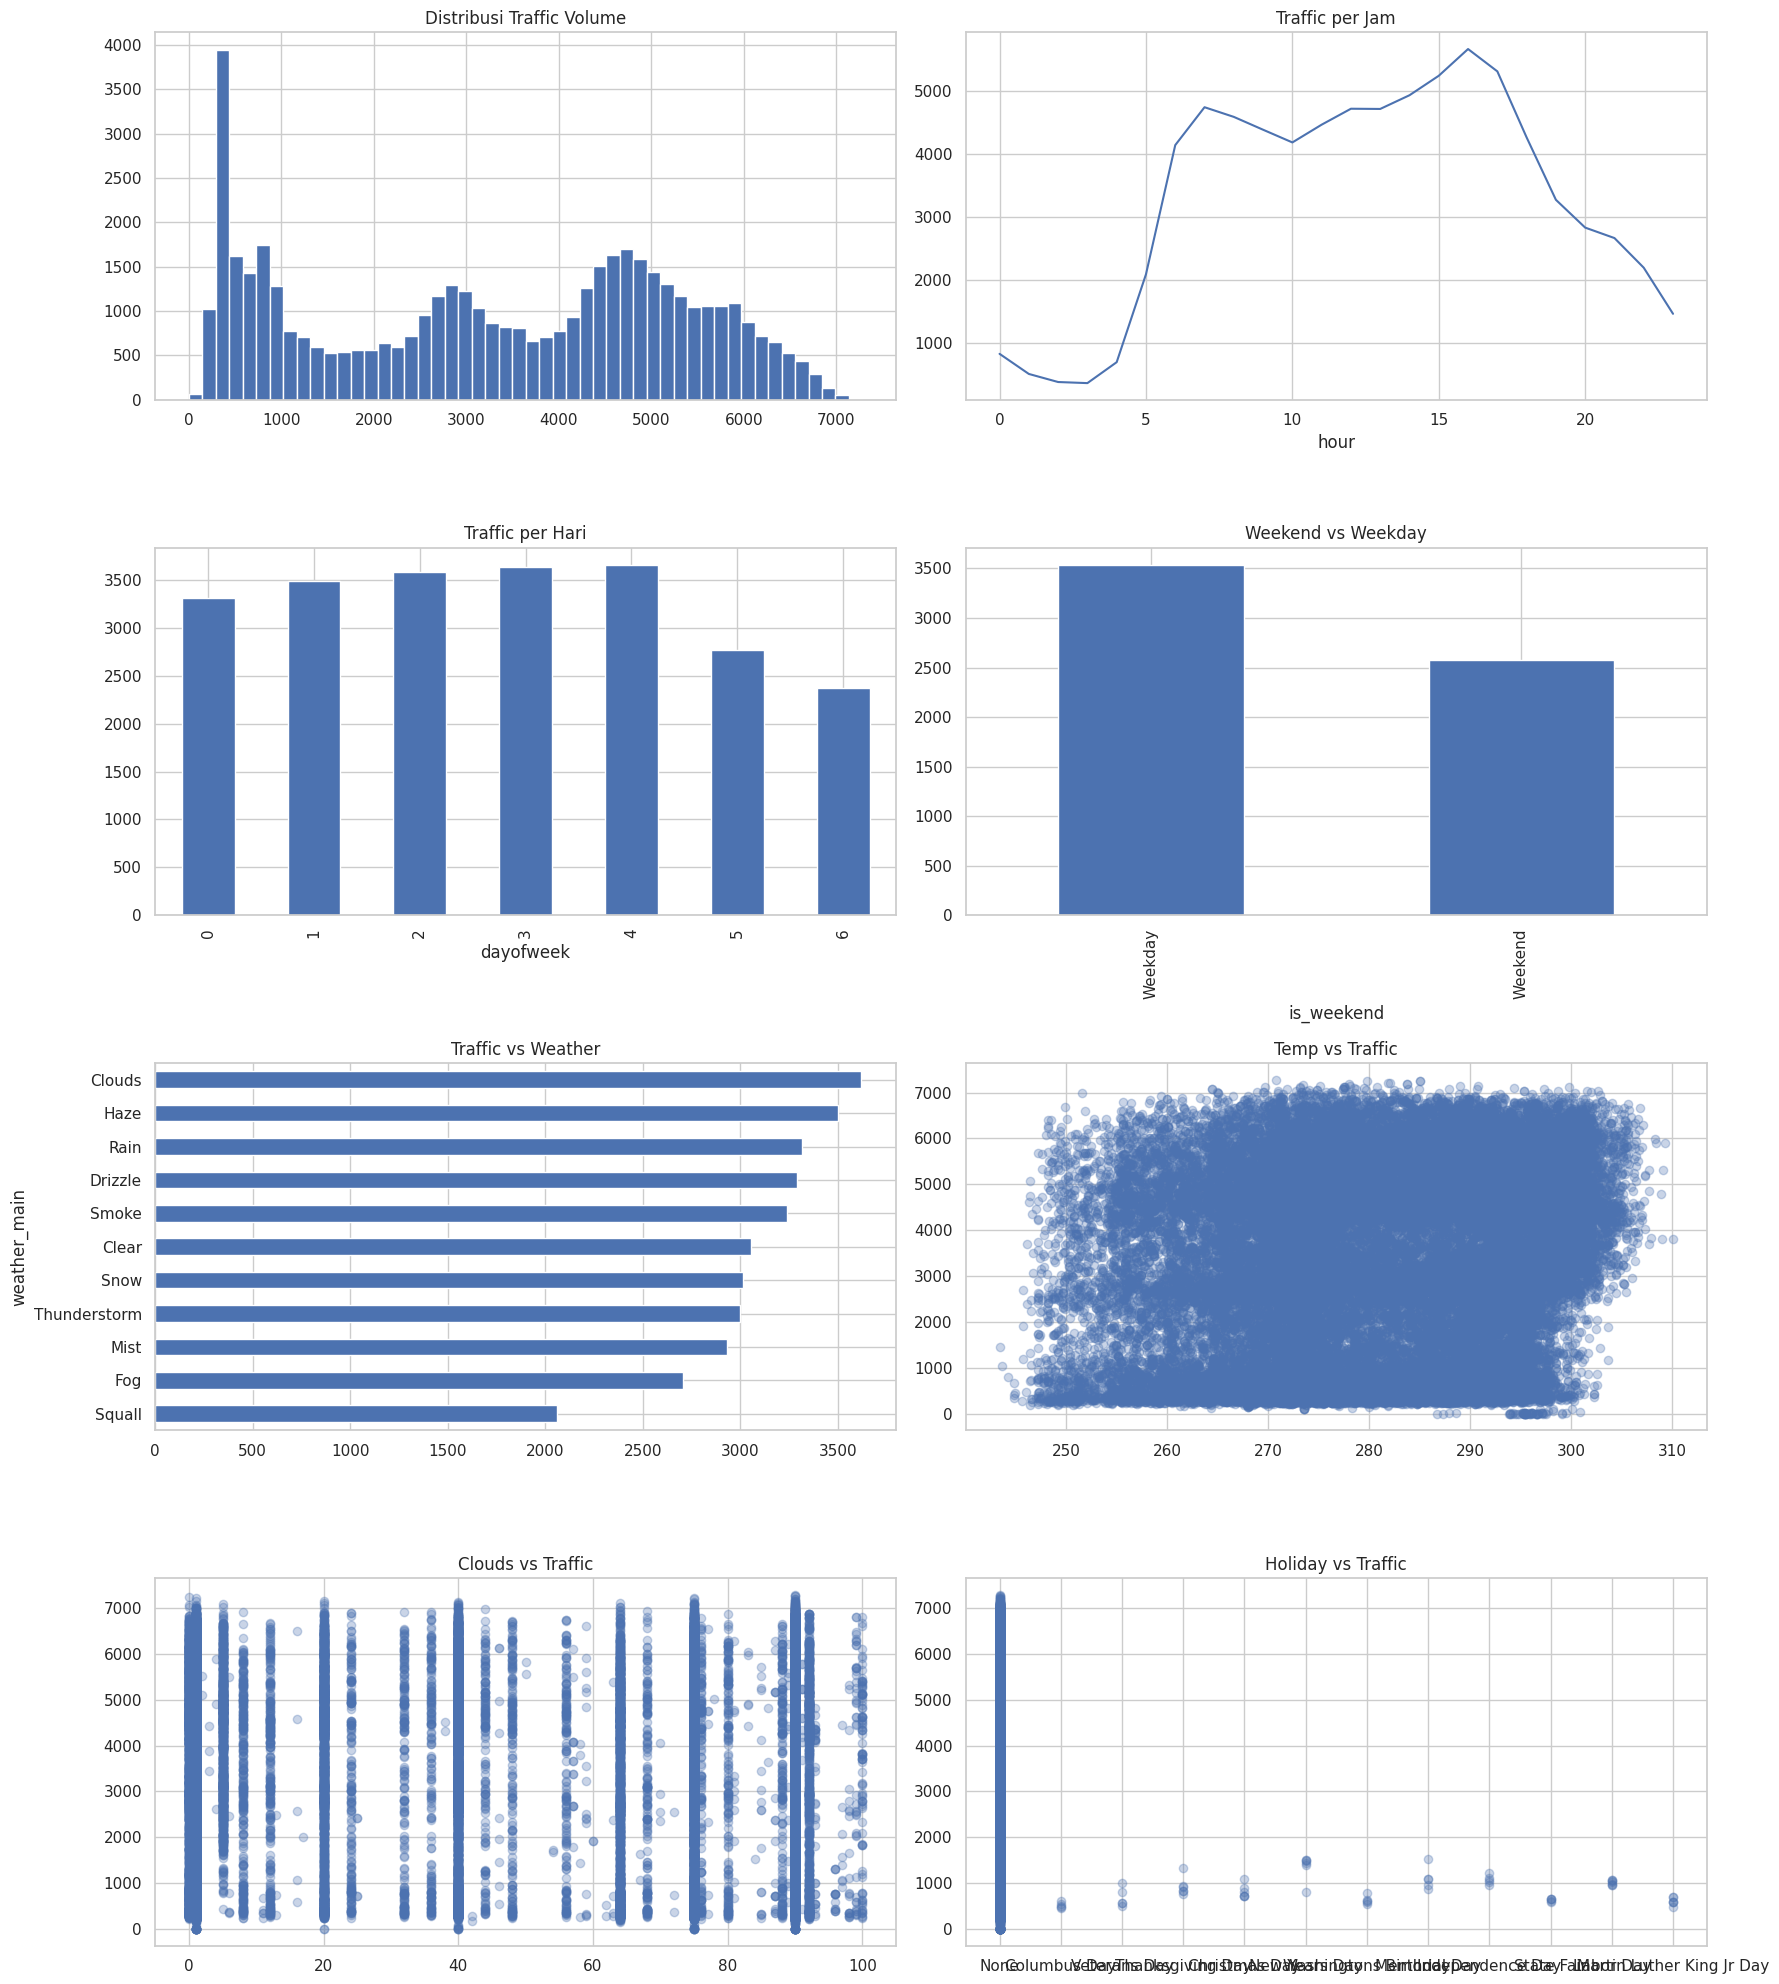

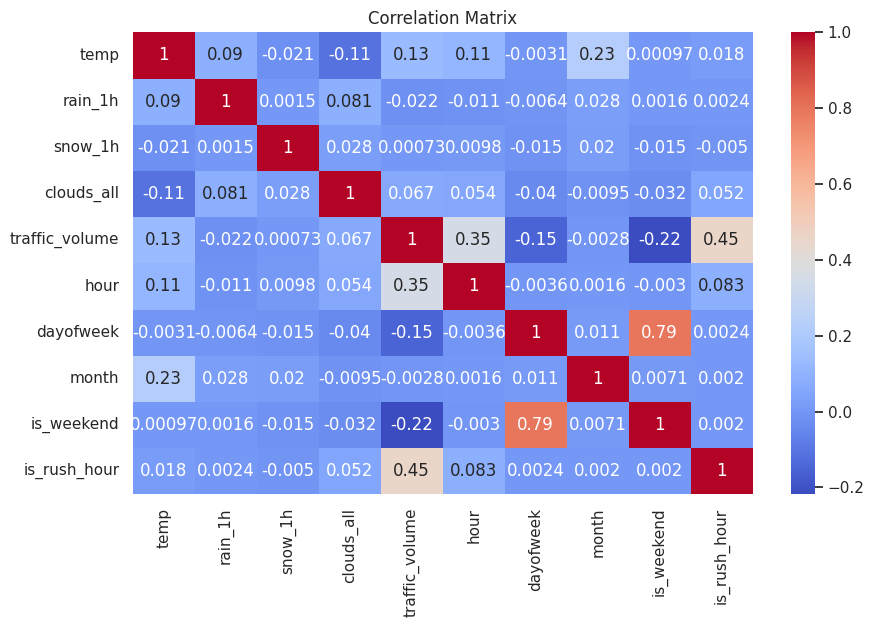

In [ ]:
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(18, 20))

# 1. Distribusi traffic
plt.subplot(4,2,1)
df_clean['traffic_volume'].hist(bins=50)
plt.title('Distribusi Traffic Volume')

# 2. Traffic vs jam
plt.subplot(4,2,2)
df_clean.groupby('hour')['traffic_volume'].mean().plot()
plt.title('Traffic per Jam')

# 3. Traffic vs hari
plt.subplot(4,2,3)
df_clean.groupby('dayofweek')['traffic_volume'].mean().plot(kind='bar')
plt.title('Traffic per Hari')

# 4. Weekend vs weekday
plt.subplot(4,2,4)
df_clean.groupby('is_weekend')['traffic_volume'].mean().plot(kind='bar')
plt.xticks([0,1], ['Weekday', 'Weekend'])
plt.title('Weekend vs Weekday')

# 5. Weather vs traffic
plt.subplot(4,2,5)
df_clean.groupby('weather_main')['traffic_volume'].mean().sort_values().plot(kind='barh')
plt.title('Traffic vs Weather')

# 6. Temp vs traffic
plt.subplot(4,2,6)
plt.scatter(df_clean['temp'], df_clean['traffic_volume'], alpha=0.3)
plt.title('Temp vs Traffic')

# 7. Clouds vs traffic
plt.subplot(4,2,7)
plt.scatter(df_clean['clouds_all'], df_clean['traffic_volume'], alpha=0.3)
plt.title('Clouds vs Traffic')

# 7. Clouds vs traffic
plt.subplot(4,2,8)
plt.scatter(df_clean['holiday'], df_clean['traffic_volume'], alpha=0.3)
plt.title('Holiday vs Traffic')

plt.tight_layout()
plt.show()

# =========================
# 4. CORRELATION MATRIX
# =========================
print('\n')
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# FEATURE ENGINEERING

In [ ]:
df_clean.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,dayofweek,month,is_weekend,is_rush_hour
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,0,1
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,0,0
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,0,0
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,0,0
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,0,0


In [ ]:
df_fe = df_clean.copy()

df_fe = pd.get_dummies(df_fe, columns=['weather_main'], prefix='weather_main')

df_fe = df_fe.drop(columns=[
    'holiday',
    'date_time',
    'weather_description'
])

features = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'hour',
    'dayofweek',
    'month',
    'is_weekend',
    'is_rush_hour',
    'weather_main_Clouds',
    'weather_main_Drizzle',
    'weather_main_Fog',
    'weather_main_Haze',
    'weather_main_Mist',
    'weather_main_Rain',
    'weather_main_Smoke',
    'weather_main_Snow',
    'weather_main_Squall',
    'weather_main_Thunderstorm'
]

# Pastikan semua kolom ada
for col in features:
    if col not in df_fe.columns:
        df_fe[col] = 0

X = df_fe[features]
y = df_fe['traffic_volume']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nColumns:")
print(X.columns)
X.head()

Shape X: (48176, 19)
Shape y: (48176,)

Columns:
Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'dayofweek',
       'month', 'is_weekend', 'is_rush_hour', 'weather_main_Clouds',
       'weather_main_Drizzle', 'weather_main_Fog', 'weather_main_Haze',
       'weather_main_Mist', 'weather_main_Rain', 'weather_main_Smoke',
       'weather_main_Snow', 'weather_main_Squall',
       'weather_main_Thunderstorm'],
      dtype='object')


,temp,rain_1h,snow_1h,clouds_all,hour,dayofweek,month,is_weekend,is_rush_hour,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,288.28,0.0,0.0,40,9,1,10,0,1,True,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,10,1,10,0,0,True,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,11,1,10,0,0,True,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,12,1,10,0,0,True,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,13,1,10,0,0,True,False,False,False,False,False,False,False,False,False


# TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODEL

In [ ]:
!pip install catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.9 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def objective(trial):

    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count': trial.suggest_int('border_count', 32, 255),

        'loss_function': 'RMSE',
        'verbose': 0
    }

    model = CatBoostRegressor(**params)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = mean_squared_error(y_test, preds)
    rmse = rmse ** 0.5

    return rmse

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("Best params:", study.best_params)
print("Best RMSE:", study.best_value)

[I 2026-04-13 09:38:12,653] A new study created in memory with name: no-name-f89f5bb6-4b5d-4dea-81e8-07840c60e906
[I 2026-04-13 09:38:18,975] Trial 0 finished with value: 425.8207713172811 and parameters: {'iterations': 935, 'depth': 4, 'learning_rate': 0.2120598888817078, 'l2_leaf_reg': 6.327079711121298, 'random_strength': 4.939004584914086, 'bagging_temperature': 0.7145737956707066, 'border_count': 153}. Best is trial 0 with value: 425.8207713172811.
[I 2026-04-13 09:38:22,167] Trial 1 finished with value: 496.21854286475184 and parameters: {'iterations': 575, 'depth': 5, 'learning_rate': 0.018454864694872248, 'l2_leaf_reg': 3.257846832428623, 'random_strength': 5.2541815814942625, 'bagging_temperature': 0.6038183085246022, 'border_count': 49}. Best is trial 0 with value: 425.8207713172811.
[I 2026-04-13 09:38:43,221] Trial 2 finished with value: 388.2782736473437 and parameters: {'iterations': 943, 'depth': 10, 'learning_rate': 0.20296300347643817, 'l2_leaf_reg': 5.759971544483468,

Best params: {'iterations': 934, 'depth': 10, 'learning_rate': 0.184540877448936, 'l2_leaf_reg': 6.86916579883979, 'random_strength': 9.801161649011409, 'bagging_temperature': 0.3129852704922116, 'border_count': 130}
Best RMSE: 387.8091973138998


In [ ]:
best_params = study.best_params

model = CatBoostRegressor(
    **best_params,
    loss_function='RMSE',
    verbose=100
)

model.fit(X_train, y_train)

0:	learn: 1698.5581071	total: 20.1ms	remaining: 18.8s
100:	learn: 427.6668355	total: 1.65s	remaining: 13.6s
200:	learn: 376.5682213	total: 3.52s	remaining: 12.8s
300:	learn: 352.1028692	total: 5.38s	remaining: 11.3s
400:	learn: 333.8938911	total: 7.32s	remaining: 9.73s
500:	learn: 319.7750361	total: 9.77s	remaining: 8.44s
600:	learn: 308.1116296	total: 12.7s	remaining: 7.02s
700:	learn: 296.8097472	total: 14.4s	remaining: 4.79s
800:	learn: 287.5965623	total: 16.2s	remaining: 2.69s
900:	learn: 279.1937554	total: 18s	remaining: 660ms
933:	learn: 277.0402370	total: 18.6s	remaining: 0us


CatBoostRegressor(bagging_temperature=0.3129852704922116, border_count=130, depth=10, iterations=934, l2_leaf_reg=6.86916579883979, learning_rate=0.184540877448936, loss_function='RMSE', random_strength=9.801161649011409, verbose=100)

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 231.2995441377411
RMSE: 387.8091973138998
R2  : 0.9618167068800847


In [ ]:
y_train_pred = model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = mean_squared_error(y_train, y_train_pred) ** 0.5
r2_train = r2_score(y_train, y_train_pred)

print("=== TRAIN PERFORMANCE ===")
print(f"MAE  : {mae_train:.2f}")
print(f"RMSE : {rmse_train:.2f}")
print(f"R2   : {r2_train:.4f}")

=== TRAIN PERFORMANCE ===
MAE  : 170.81
RMSE : 277.04
R2   : 0.9806


In [ ]:
importance = pd.Series(model.get_feature_importance(), index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
hour,74.554494
dayofweek,8.117185
is_weekend,6.248858
is_rush_hour,3.631556
temp,2.676805
month,2.326146
clouds_all,1.278046
weather_main_Clouds,0.481814
rain_1h,0.245719
weather_main_Mist,0.136941


# LATIHAN TEST

In [ ]:
import pandas as pd

test_data = pd.DataFrame([
    # 🚗 1. Pagi rush hour (macet)
    {
        'temp': 285,
        'rain_1h': 0,
        'snow_1h': 0,
        'clouds_all': 80,
        'hour': 8,
        'dayofweek': 1,
        'month': 10,
        'is_weekend': 0,
        'is_rush_hour': 1,
        'weather_main_Clouds': 1,
        'weather_main_Drizzle': 0,
        'weather_main_Fog': 0,
        'weather_main_Haze': 0,
        'weather_main_Mist': 0,
        'weather_main_Rain': 0,
        'weather_main_Smoke': 0,
        'weather_main_Snow': 0,
        'weather_main_Squall': 0,
        'weather_main_Thunderstorm': 0
    },

    # 🌙 2. Malam (sepi)
    {
        'temp': 280,
        'rain_1h': 0,
        'snow_1h': 0,
        'clouds_all': 20,
        'hour': 2,
        'dayofweek': 3,
        'month': 10,
        'is_weekend': 0,
        'is_rush_hour': 0,
        'weather_main_Clouds': 0,
        'weather_main_Drizzle': 0,
        'weather_main_Fog': 0,
        'weather_main_Haze': 0,
        'weather_main_Mist': 0,
        'weather_main_Rain': 0,
        'weather_main_Smoke': 0,
        'weather_main_Snow': 0,
        'weather_main_Squall': 0,
        'weather_main_Thunderstorm': 0
    },

    # 🌧️ 3. Hujan + sore (lumayan padat)
    {
        'temp': 283,
        'rain_1h': 5,
        'snow_1h': 0,
        'clouds_all': 90,
        'hour': 17,
        'dayofweek': 4,
        'month': 10,
        'is_weekend': 0,
        'is_rush_hour': 1,
        'weather_main_Clouds': 0,
        'weather_main_Drizzle': 0,
        'weather_main_Fog': 0,
        'weather_main_Haze': 0,
        'weather_main_Mist': 0,
        'weather_main_Rain': 1,
        'weather_main_Smoke': 0,
        'weather_main_Snow': 0,
        'weather_main_Squall': 0,
        'weather_main_Thunderstorm': 0
    },

    # 🏖️ 4. Weekend siang
    {
        'temp': 295,
        'rain_1h': 0,
        'snow_1h': 0,
        'clouds_all': 30,
        'hour': 13,
        'dayofweek': 6,
        'month': 7,
        'is_weekend': 1,
        'is_rush_hour': 0,
        'weather_main_Clouds': 0,
        'weather_main_Drizzle': 0,
        'weather_main_Fog': 0,
        'weather_main_Haze': 0,
        'weather_main_Mist': 0,
        'weather_main_Rain': 0,
        'weather_main_Smoke': 0,
        'weather_main_Snow': 0,
        'weather_main_Squall': 0,
        'weather_main_Thunderstorm': 0
    }
])

preds = model.predict(test_data)

for i, p in enumerate(preds):
    print(f"Scenario {i+1} Prediction: {p:.2f}")

Scenario 1 Prediction: 5801.46
Scenario 2 Prediction: 215.01
Scenario 3 Prediction: 5466.90
Scenario 4 Prediction: 4246.75


# SAVE MODEL

In [ ]:
import joblib

joblib.dump(model, "traffic_model.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [ ]:
joblib.dump(X_train.columns.tolist(), "feature_order.pkl")

['feature_order.pkl']

In [ ]:
df_fe.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,dayofweek,month,is_weekend,is_rush_hour,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,288.28,0.0,0.0,40,5545,9,1,10,0,1,...,True,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,4516,10,1,10,0,0,...,True,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,4767,11,1,10,0,0,...,True,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,5026,12,1,10,0,0,...,True,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,4918,13,1,10,0,0,...,True,False,False,False,False,False,False,False,False,False
